# EDA — Dataset Simu5G

Analyse de distribution avant entraînement LSTM.

Colonnes : `Time_Sec, Slice_Type, gNB_id, Scenario, Slice_Throughput_Mbps, Slice_Latency_ms, Slice_Packet_Loss_pct, ...`

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

CSV_PATH = 'all_simu5g.csv'
OUT_DIR  = 'eda_output/'
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)

# Alias courts pour simplifier le code
df['scenario']    = df['Scenario']
df['slice']       = df['Slice_Type']
df['gnb']         = df['gNB_id']
df['pkt_loss']    = df['Slice_Packet_Loss_pct']
df['throughput']  = df['Slice_Throughput_Mbps']
df['latency']     = df['Slice_Latency_ms']

print(f'Lignes      : {len(df):,}')
print(f'Scénarios   : {df["scenario"].nunique()} -> {sorted(df["scenario"].unique())}')
print(f'gNBs        : {sorted(df["gnb"].unique())}')
print(f'Slices      : {sorted(df["slice"].unique())}')
print(f'Colonnes    : {list(df.columns[:8])}')
df.head(3)

Lignes      : 183,812
Scénarios   : 12 -> ['FifaWorldCup_Commerce', 'GlobalSaturation', 'HetLoad_Asymmetric_A', 'HetLoad_Asymmetric_B', 'HetLoad_Asymmetric_C', 'KddiOutage_Storm', 'LowTrafficNight', 'ModerateLoad_URLLC', 'ModerateLoad_eMBB', 'NormalLoad', 'OverloadeMBB_Commerce', 'SLABoundary_URLLC']
gNBs        : ['Commerce', 'Industrie', 'Macro']
Slices      : ['URLLC', 'eMBB', 'mMTC']
Colonnes    : ['Time_Sec', 'Slice_Type', 'gNB_id', 'Scenario', 'Slice_Throughput_Mbps', 'Slice_Latency_ms', 'Slice_Jitter_ms', 'Slice_Packet_Loss_pct']


,Time_Sec,Slice_Type,gNB_id,Scenario,Slice_Throughput_Mbps,Slice_Latency_ms,Slice_Jitter_ms,Slice_Packet_Loss_pct,Slice_Network_Load_pct,SLA_Throughput_Min_Mbps,...,SLA_PacketLoss_Max_pct,SLA_OK,SLA_OK_in_15s,SLA_Violated_in_15s,scenario,slice,gnb,pkt_loss,throughput,latency
0,2024-01-01T00:00:00Z,URLLC,Commerce,FifaWorldCup_Commerce,0.6752,42.232162,0.0,54.769561,13.504,0.5,...,0.001,False,False,1,FifaWorldCup_Commerce,URLLC,Commerce,54.769561,0.6752,42.232162
1,2024-01-01T00:00:00Z,URLLC,Commerce,GlobalSaturation,1.2128,66.327834,0.0,47.760165,24.256,0.5,...,0.001,False,False,1,GlobalSaturation,URLLC,Commerce,47.760165,1.2128,66.327834
2,2024-01-01T00:00:00Z,URLLC,Commerce,HetLoad_Asymmetric_A,0.2224,14.141423,0.0,2.112676,4.448,0.5,...,0.001,False,False,1,HetLoad_Asymmetric_A,URLLC,Commerce,2.112676,0.2224,14.141423


## 1. Qualité des données

In [26]:
print('=== Valeurs manquantes ===')
print(df[['latency','throughput','pkt_loss']].isnull().sum())

print('\n=== Statistiques globales ===')
print(df[['latency','throughput','pkt_loss']].describe().round(3))

print('\n=== Vérifications de cohérence ===')
print(f'  pkt_loss hors [0,100] : {((df["pkt_loss"] < 0) | (df["pkt_loss"] > 100)).sum()} lignes')
print(f'  throughput < 0        : {(df["throughput"] < 0).sum()} lignes')
print(f'  latency < 0           : {(df["latency"] < 0).sum()} lignes')

print('\n=== Périodes par scénario ===')
print(df.groupby('scenario')['Time_Sec'].nunique().sort_values())

=== Valeurs manquantes ===
latency       0
throughput    0
pkt_loss      0
dtype: int64

=== Statistiques globales ===
          latency  throughput    pkt_loss
count  183812.000  183812.000  183812.000
mean      145.081       1.731      18.848
std       437.144       2.044      34.269
min         8.047       0.000       0.000
25%         8.722       0.010       0.000
50%        16.563       0.932       0.000
75%        67.061       3.046      13.950
max      3541.570       6.754      99.400

=== Vérifications de cohérence ===
  pkt_loss hors [0,100] : 0 lignes
  throughput < 0        : 0 lignes
  latency < 0           : 0 lignes

=== Périodes par scénario ===
scenario
HetLoad_Asymmetric_A     1296
FifaWorldCup_Commerce    1800
GlobalSaturation         1800
HetLoad_Asymmetric_B     1800
HetLoad_Asymmetric_C     1800
KddiOutage_Storm         1800
LowTrafficNight          1800
ModerateLoad_URLLC       1800
ModerateLoad_eMBB        1800
NormalLoad               1800
OverloadeMBB_Commerce 

## 2. Distribution de pkt_loss_pct

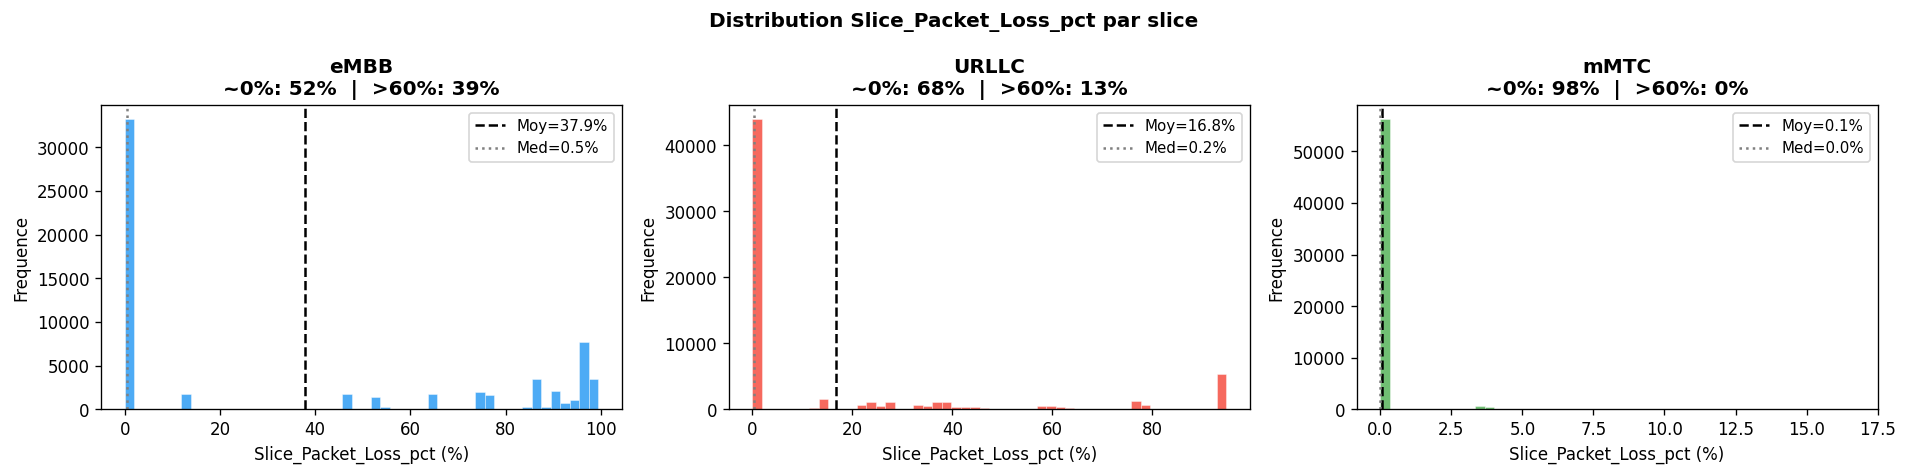

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = {'eMBB': '#2196F3', 'URLLC': '#F44336', 'mMTC': '#4CAF50'}

for ax, sl in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    sub = df[df['slice'] == sl]['pkt_loss']
    ax.hist(sub, bins=50, color=colors[sl], alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(sub.mean(),   color='black', linestyle='--', lw=1.5, label=f'Moy={sub.mean():.1f}%')
    ax.axvline(sub.median(), color='gray',  linestyle=':',  lw=1.5, label=f'Med={sub.median():.1f}%')
    pct_zero = (sub < 1).mean() * 100
    pct_high = (sub > 60).mean() * 100
    ax.set_title(f'{sl}\n~0%: {pct_zero:.0f}%  |  >60%: {pct_high:.0f}%', fontweight='bold')
    ax.set_xlabel('Slice_Packet_Loss_pct (%)')
    ax.set_ylabel('Frequence')
    ax.legend(fontsize=9)

plt.suptitle('Distribution Slice_Packet_Loss_pct par slice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '01_loss_distribution.png', bbox_inches='tight')
plt.show()

## 3. Heatmap loss par scénario × (gNB, slice)

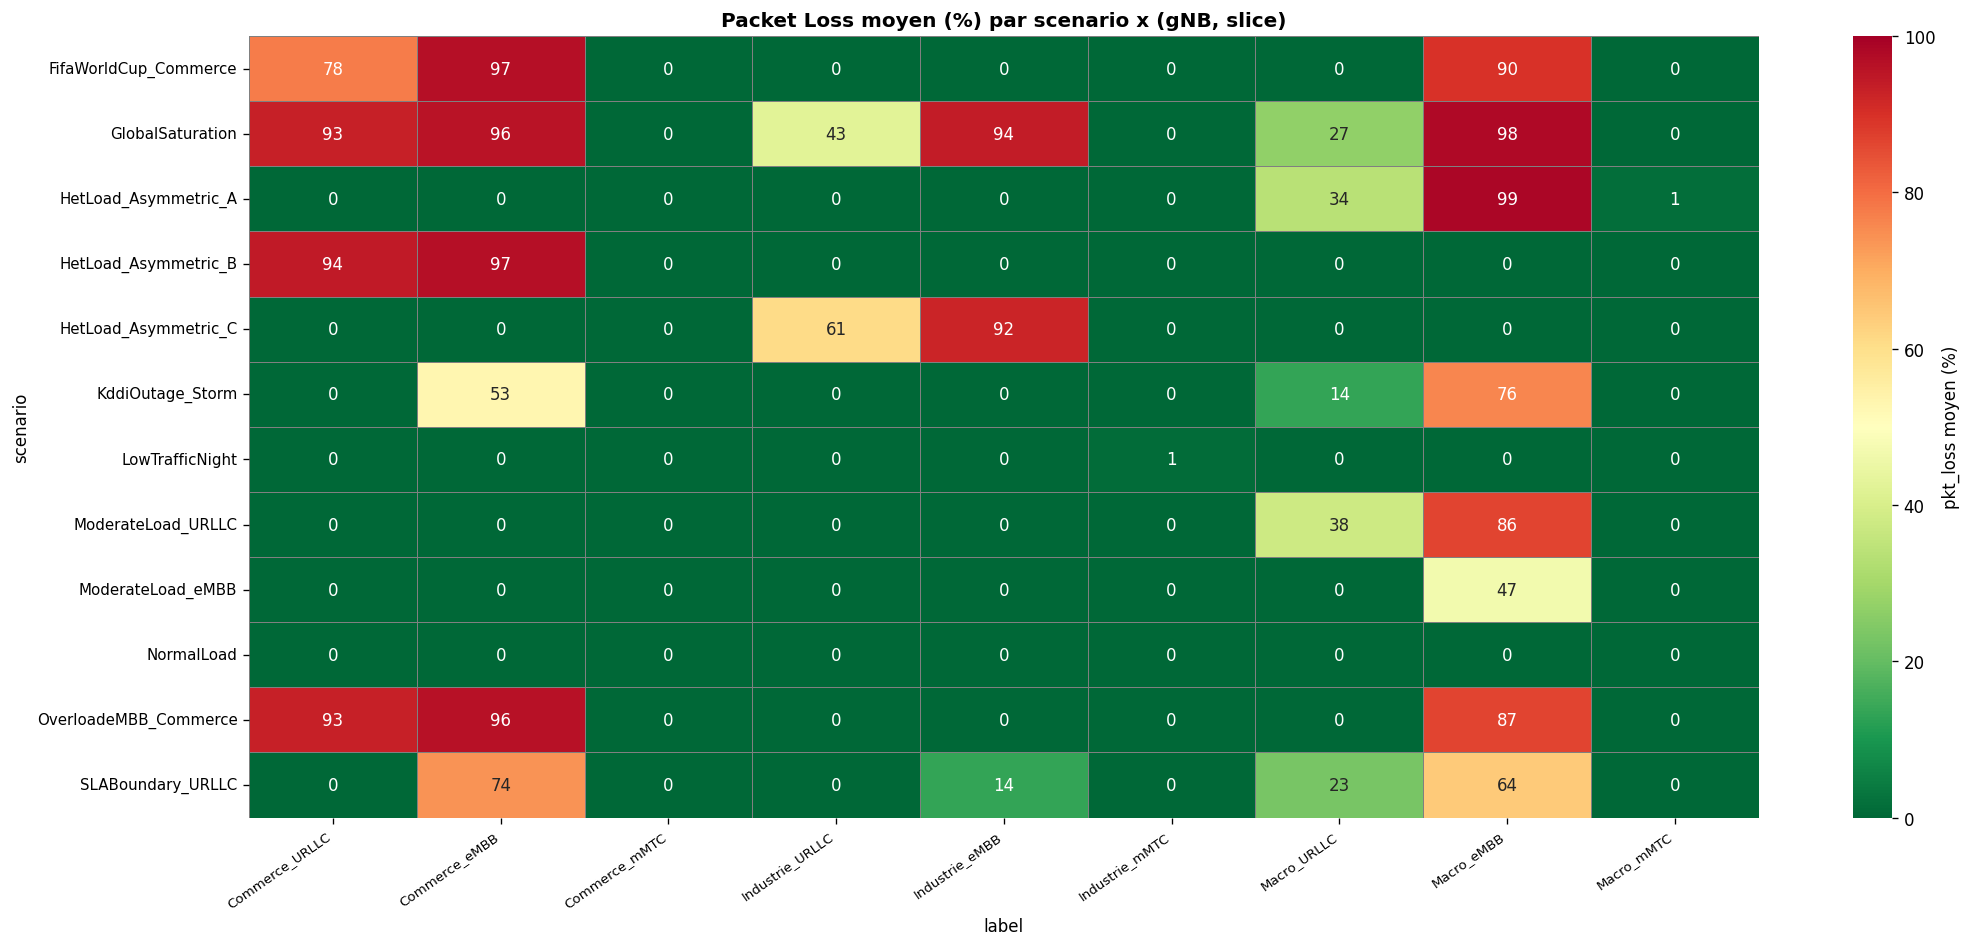

In [28]:
pivot = df.groupby(['scenario','gnb','slice'])['pkt_loss'].mean().reset_index()
pivot['label'] = pivot['gnb'] + '_' + pivot['slice']
hm = pivot.pivot_table(index='scenario', columns='label', values='pkt_loss')

fig, ax = plt.subplots(figsize=(18, 8))
sns.heatmap(hm, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, linewidths=0.5, linecolor='gray',
            ax=ax, cbar_kws={'label': 'pkt_loss moyen (%)'})
ax.set_title('Packet Loss moyen (%) par scenario x (gNB, slice)', fontsize=12, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + '02_heatmap_scenario.png', bbox_inches='tight')
plt.show()

## 4. Equilibre des classes (pour LSTM)

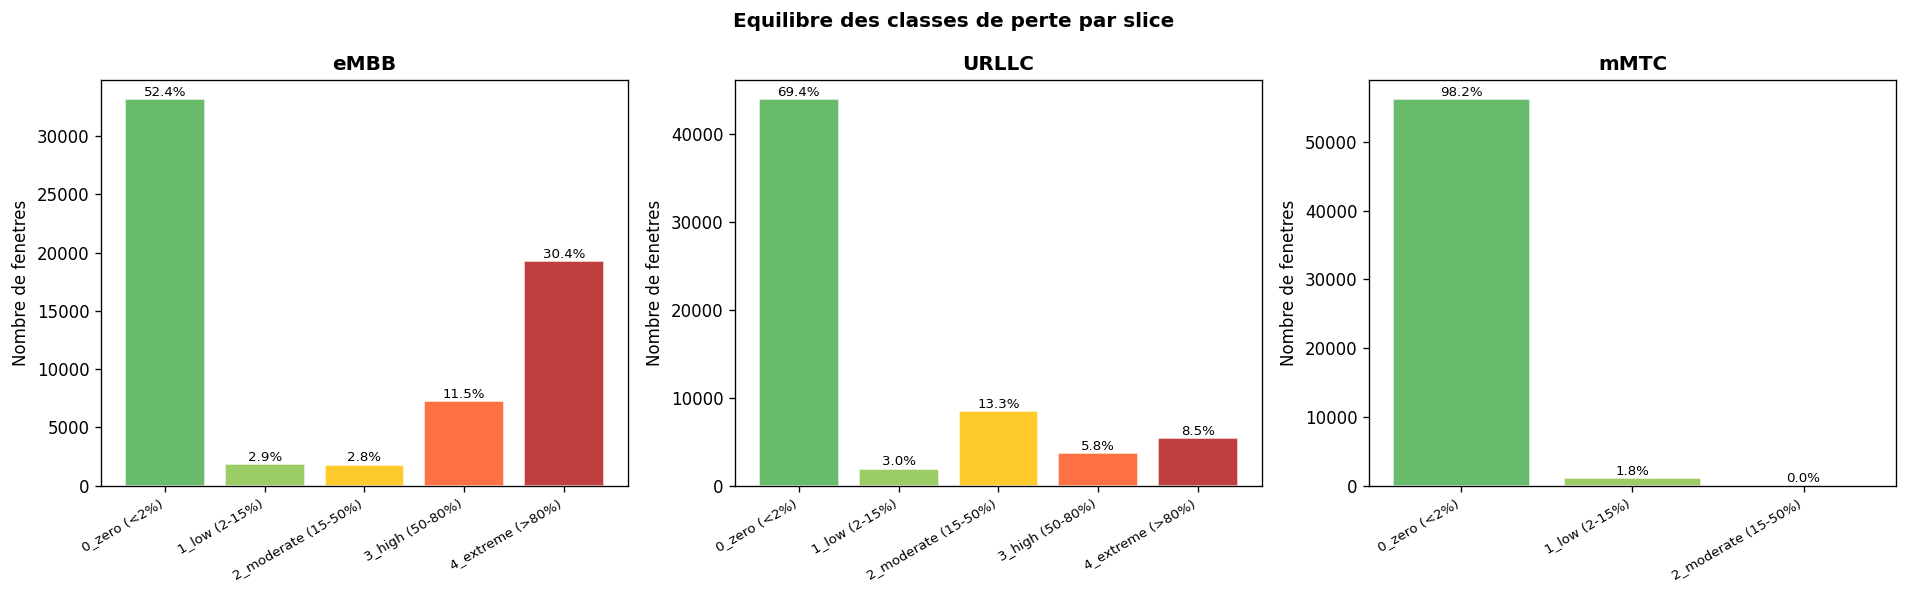


=== Resume classes ===
loss_class  0_zero (<2%)  1_low (2-15%)  2_moderate (15-50%)  3_high (50-80%)  \
slice                                                                           
URLLC              43899           1893                 8428             3671   
eMBB               33173           1819                 1802             7252   
mMTC               56203           1032                    1                0   

loss_class  4_extreme (>80%)  
slice                         
URLLC                   5397  
eMBB                   19242  
mMTC                       0  


In [29]:
def classify_loss(x):
    if x < 2:   return '0_zero (<2%)'
    if x < 15:  return '1_low (2-15%)'
    if x < 50:  return '2_moderate (15-50%)'
    if x < 80:  return '3_high (50-80%)'
    return '4_extreme (>80%)'

df['loss_class'] = df['pkt_loss'].apply(classify_loss)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = ['#4CAF50','#8BC34A','#FFC107','#FF5722','#B71C1C']

for ax, sl in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    sub = df[df['slice'] == sl]['loss_class'].value_counts().sort_index()
    bars = ax.bar(range(len(sub)), sub.values, color=palette[:len(sub)], alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(sub)))
    ax.set_xticklabels(sub.index, rotation=30, ha='right', fontsize=8)
    ax.set_title(f'{sl}', fontweight='bold')
    ax.set_ylabel('Nombre de fenetres')
    for bar, val in zip(bars, sub.values):
        pct = val / len(df[df['slice'] == sl]) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Equilibre des classes de perte par slice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '03_class_balance.png', bbox_inches='tight')
plt.show()

print('\n=== Resume classes ===')
print(df.groupby(['slice','loss_class']).size().unstack(fill_value=0))

## 5. Correlations entre features

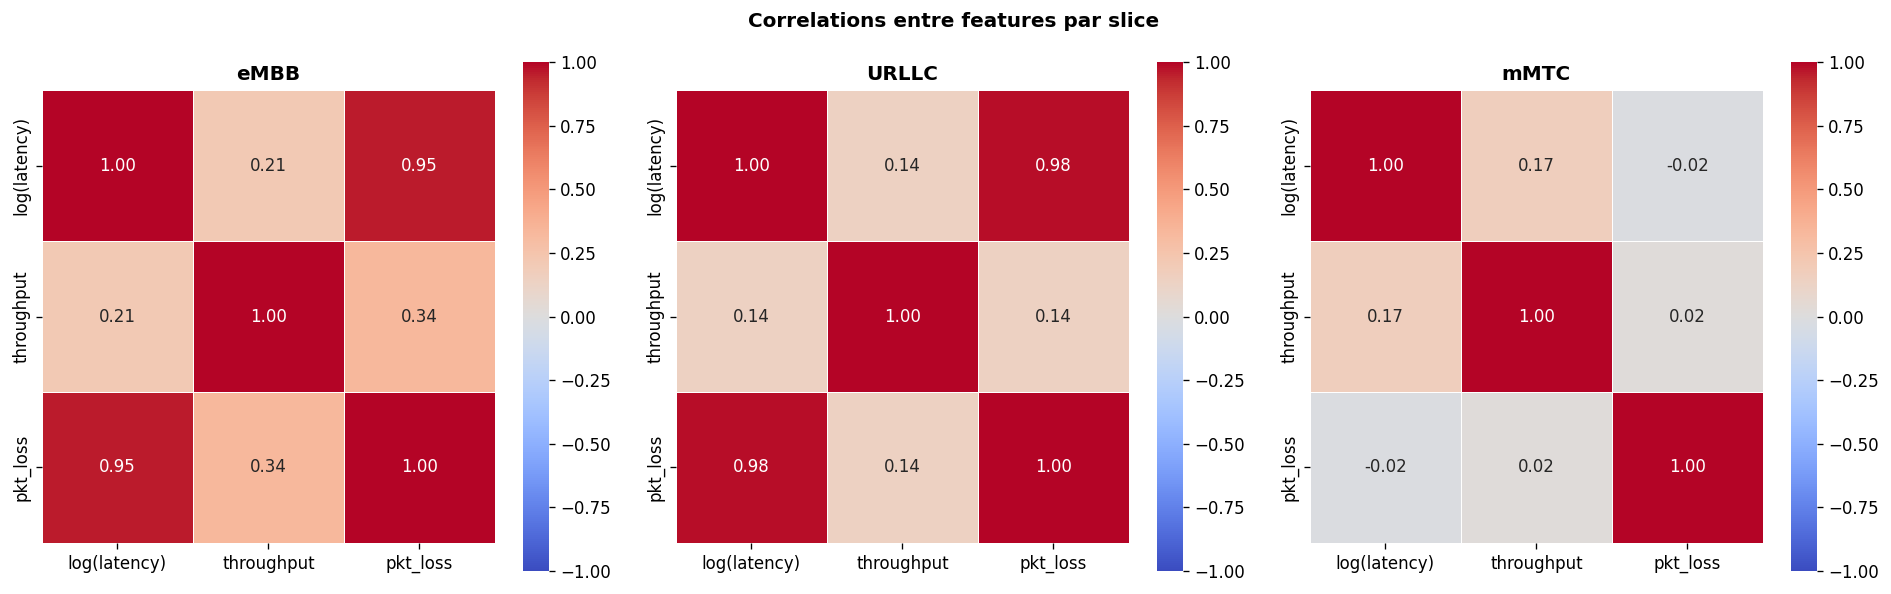

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, sl in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    sub = df[df['slice'] == sl][['latency','throughput','pkt_loss']].copy()
    sub['log_latency'] = np.log1p(sub['latency'])
    corr = sub[['log_latency','throughput','pkt_loss']].corr()
    corr.index   = ['log(latency)', 'throughput', 'pkt_loss']
    corr.columns = ['log(latency)', 'throughput', 'pkt_loss']
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
                vmin=-1, vmax=1, ax=ax, square=True, linewidths=0.5)
    ax.set_title(f'{sl}', fontweight='bold')

plt.suptitle('Correlations entre features par slice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '04_correlations.png', bbox_inches='tight')
plt.show()

## 6. Profils temporels

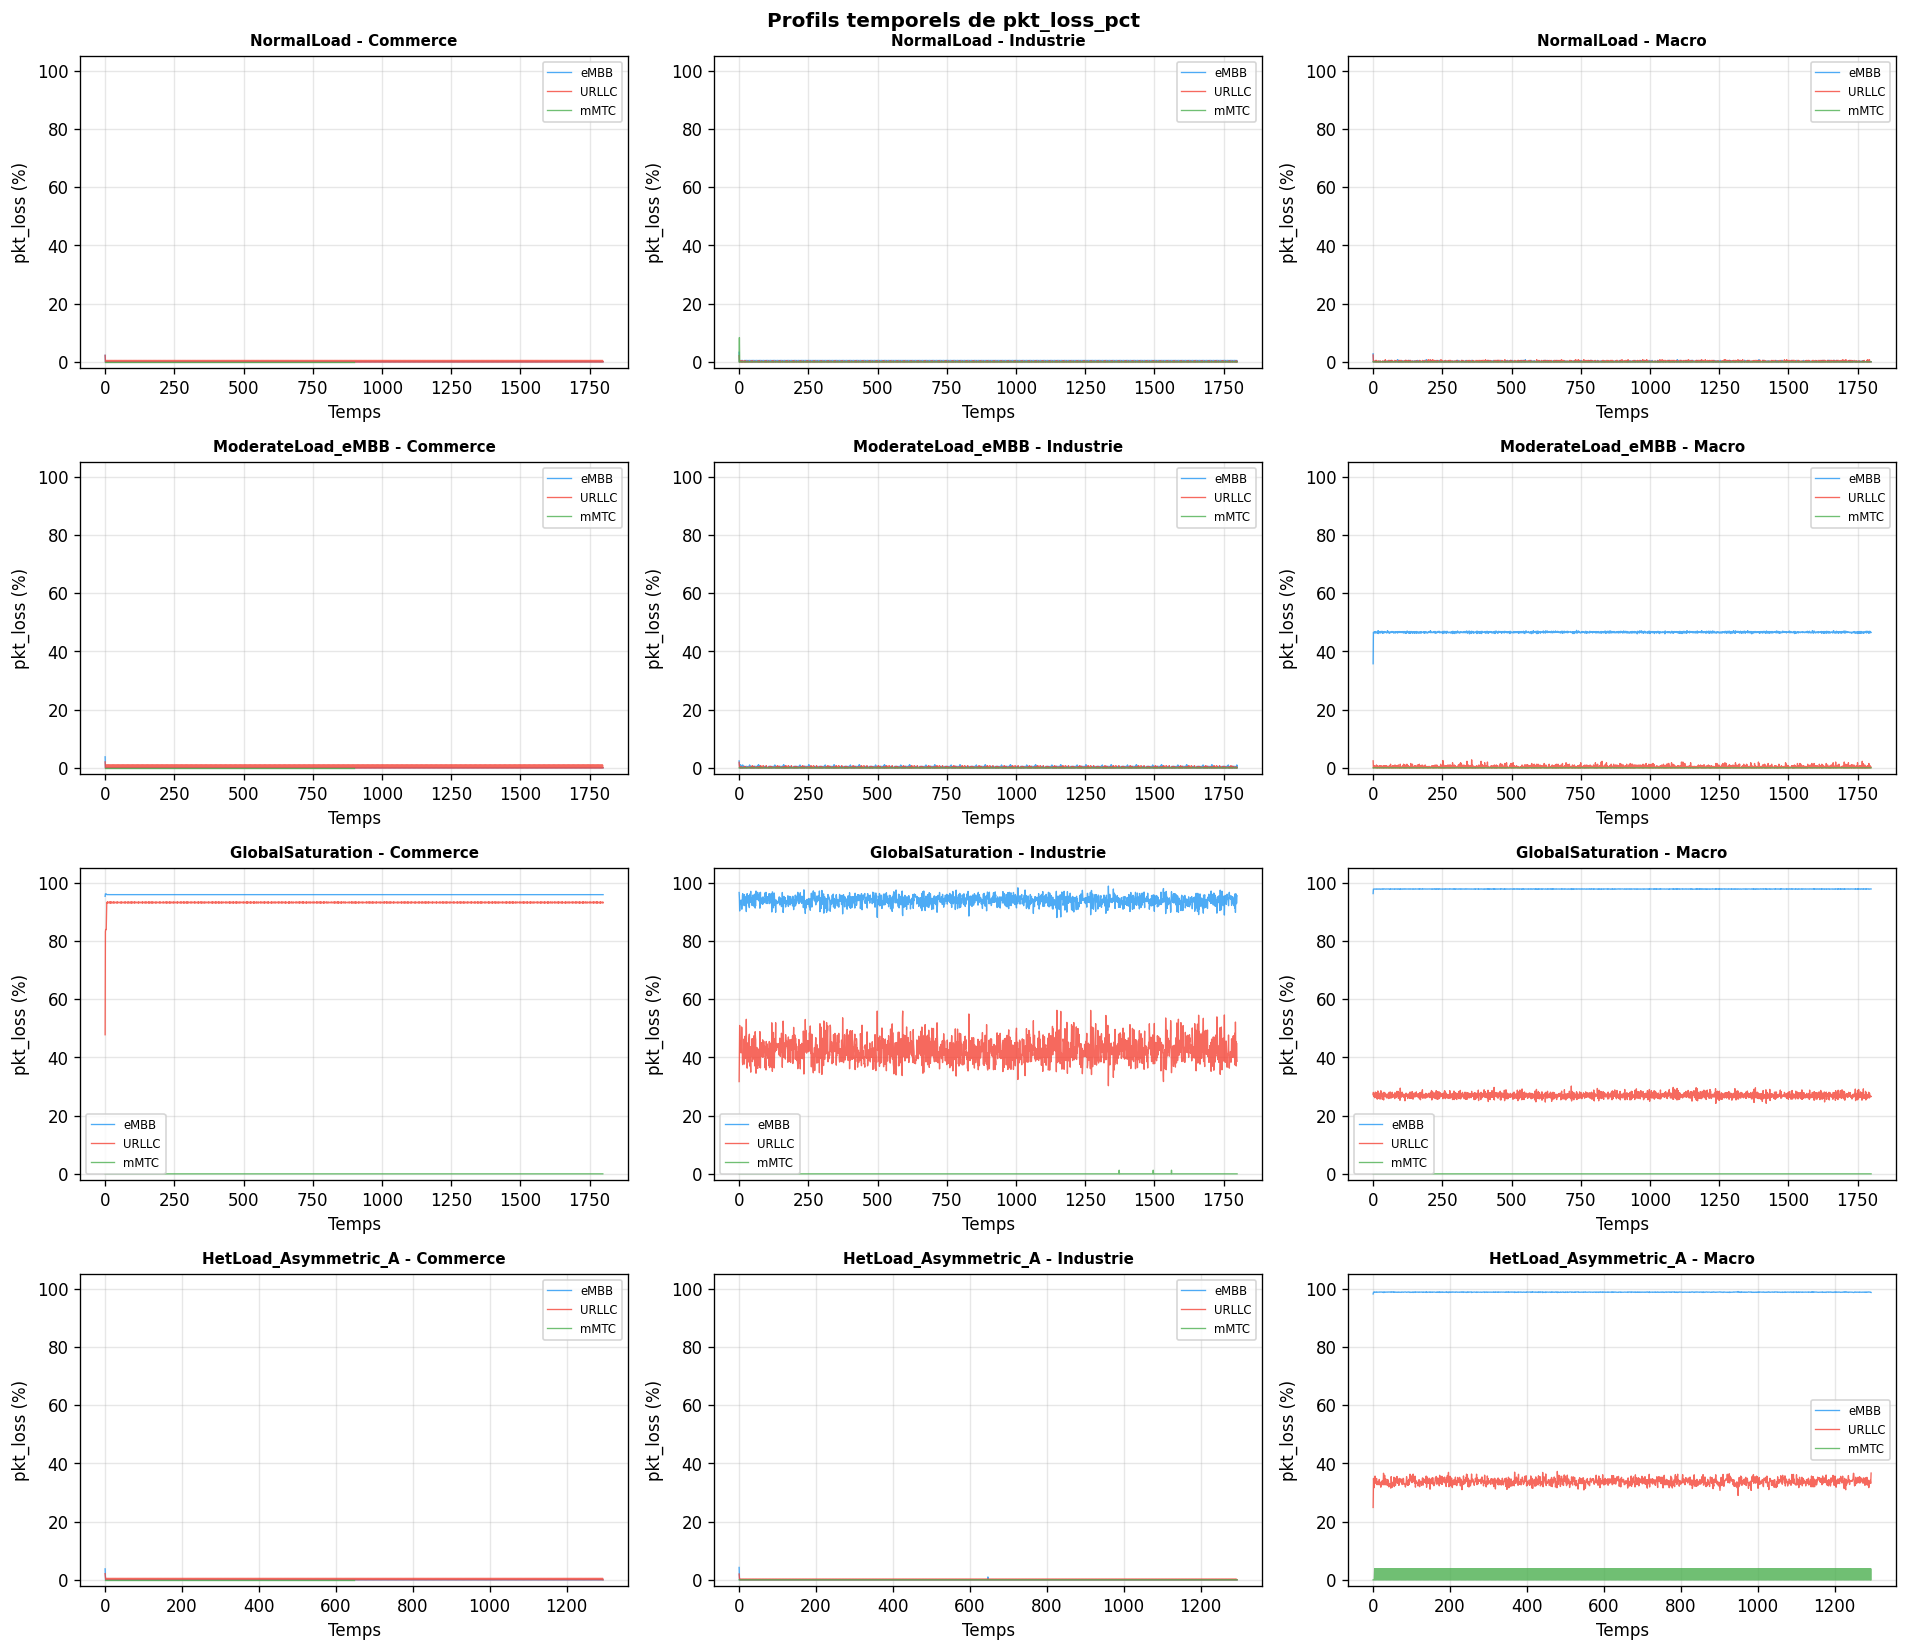

In [31]:
scenarios_sample = ['NormalLoad', 'ModerateLoad_eMBB', 'GlobalSaturation', 'HetLoad_Asymmetric_A']
scenarios_sample = [s for s in scenarios_sample if s in df['scenario'].unique()]
if not scenarios_sample:
    scenarios_sample = df['scenario'].unique()[:4].tolist()

fig, axes = plt.subplots(len(scenarios_sample), 3, figsize=(16, 3.5*len(scenarios_sample)))
if len(scenarios_sample) == 1:
    axes = [axes]

gnbs = sorted(df['gnb'].unique())
for row_axes, sc in zip(axes, scenarios_sample):
    sub = df[df['scenario'] == sc]
    for ax, gnb in zip(row_axes, gnbs):
        g = sub[sub['gnb'] == gnb]
        for sl, col in [('eMBB','#2196F3'), ('URLLC','#F44336'), ('mMTC','#4CAF50')]:
            s = g[g['slice'] == sl].sort_values('Time_Sec')
            if not s.empty:
                ax.plot(range(len(s)), s['pkt_loss'].values, color=col, lw=0.8, alpha=0.8, label=sl)
        ax.set_ylim(-2, 105)
        ax.set_title(f'{sc} - {gnb}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Temps')
        ax.set_ylabel('pkt_loss (%)')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

plt.suptitle('Profils temporels de pkt_loss_pct', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '05_temporal_profiles.png', bbox_inches='tight')
plt.show()

## 7. Non-IID check par gNB (critique pour FDL)

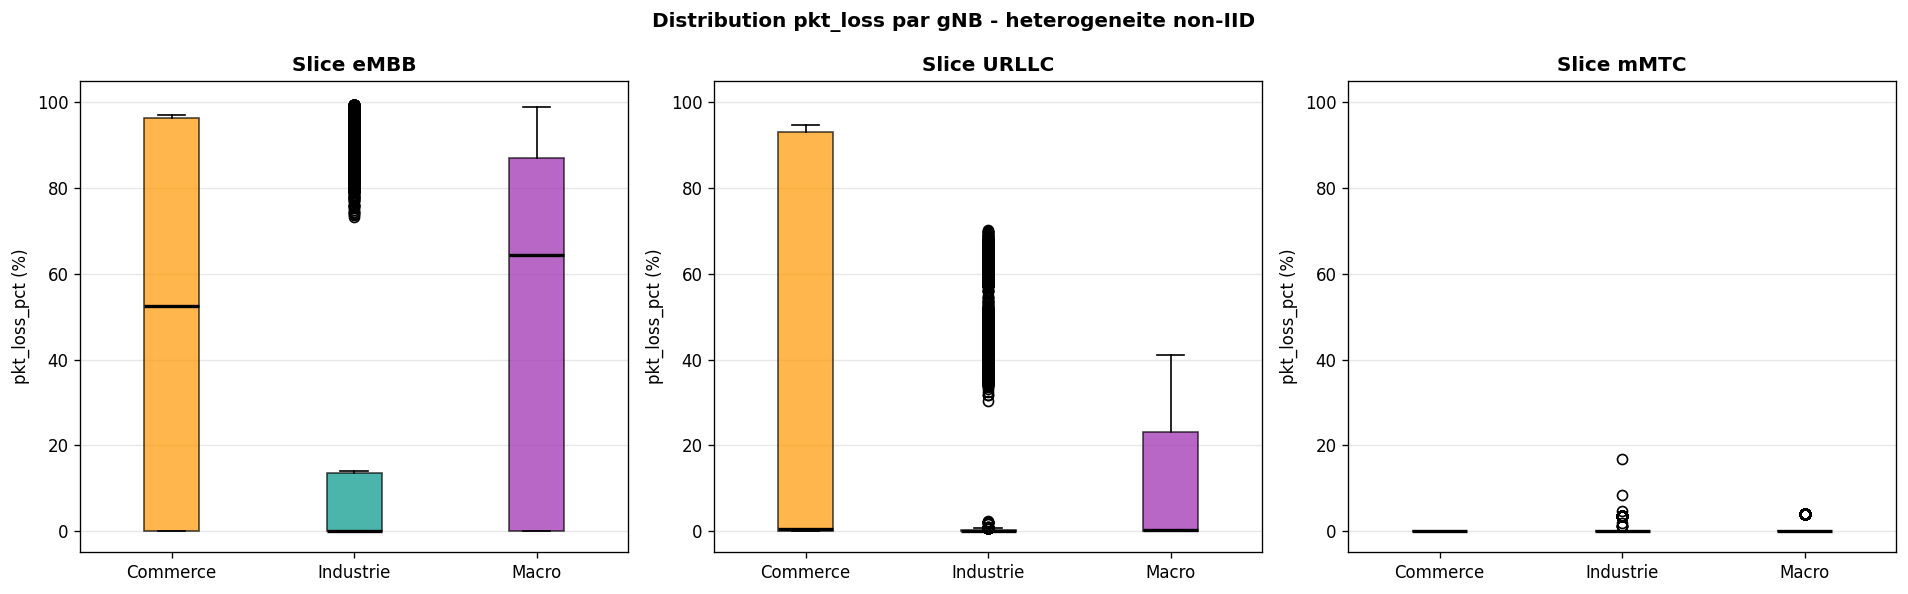

=== Moyenne pkt_loss par (gNB, slice) ===
slice      URLLC   eMBB  mMTC
gnb                          
Commerce    30.7  43.78  0.00
Industrie    8.9  17.11  0.10
Macro       10.8  52.76  0.08


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
gnb_colors = {'Macro': '#9C27B0', 'Commerce': '#FF9800', 'Industrie': '#009688'}

for ax, sl in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    sub = df[df['slice'] == sl]
    gnb_list = sorted(sub['gnb'].unique())
    data = [sub[sub['gnb'] == g]['pkt_loss'].values for g in gnb_list]
    bp = ax.boxplot(data, labels=gnb_list, patch_artist=True,
                    medianprops=dict(color='black', lw=2))
    for patch, gnb in zip(bp['boxes'], gnb_list):
        patch.set_facecolor(gnb_colors.get(gnb, '#999999'))
        patch.set_alpha(0.7)
    ax.set_title(f'Slice {sl}', fontweight='bold')
    ax.set_ylabel('pkt_loss_pct (%)')
    ax.set_ylim(-5, 105)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribution pkt_loss par gNB - heterogeneite non-IID', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '06_non_iid_gnb.png', bbox_inches='tight')
plt.show()

print('=== Moyenne pkt_loss par (gNB, slice) ===')
print(df.groupby(['gnb','slice'])['pkt_loss'].mean().round(2).unstack())

## 8. Checklist avant entrainement

In [33]:
scenario_means = df.groupby('scenario')['pkt_loss'].mean()
cell_means     = df.groupby(['scenario','gnb','slice'])['pkt_loss'].mean()

checks = {
    'Pas de valeurs manquantes'               : df[['latency','throughput','pkt_loss']].isnull().sum().sum() == 0,
    'pkt_loss dans [0, 100]'                  : ((df['pkt_loss'] >= 0) & (df['pkt_loss'] <= 100)).all(),
    'Au moins 1 scenario a ~0% perte'         : (scenario_means < 2).any(),
    'Au moins 1 cellule (gnb,slice) > 60%'   : (cell_means > 60).any(),
    'Au moins 1 scenario 15-50% perte (moy)'  : ((scenario_means > 15) & (scenario_means < 60)).any(),
    '3 gNBs presents'                         : df['gnb'].nunique() == 3,
    '3 slices presentes'                      : df['slice'].nunique() == 3,
    'SLA_OK present'                          : 'SLA_OK' in df.columns,
    '12 scenarios presents'                   : df['scenario'].nunique() == 12,
}

print('=== Checklist avant entrainement ===')
all_ok = True
for desc, ok in checks.items():
    status = 'OK' if ok else 'FAIL'
    print(f'  [{status}] {desc}')
    if not ok: all_ok = False

print()
print('Dataset pret !' if all_ok else 'Points a corriger avant entrainement.')

print('\n=== Loss moyenne par scenario (global) ===')
print(scenario_means.round(1).sort_values().to_string())

print('\n=== Cellules (scenario x gNB x slice) avec perte moyenne > 60% ===')
high = cell_means[cell_means > 60].reset_index()
high.columns = ['scenario', 'gnb', 'slice', 'pkt_loss_moy']
print(f'{len(high)} combinaisons au-dessus de 60%')
print(high.to_string(index=False))

=== Checklist avant entrainement ===
  [OK] Pas de valeurs manquantes
  [OK] pkt_loss dans [0, 100]
  [OK] Au moins 1 scenario a ~0% perte
  [OK] Au moins 1 cellule (gnb,slice) > 60%
  [OK] Au moins 1 scenario 15-50% perte (moy)
  [OK] 3 gNBs presents
  [OK] 3 slices presentes
  [OK] SLA_OK present
  [OK] 12 scenarios presents

Dataset pret !

=== Loss moyenne par scenario (global) ===
scenario
LowTrafficNight           0.1
NormalLoad                0.1
ModerateLoad_eMBB         5.6
ModerateLoad_URLLC       14.7
HetLoad_Asymmetric_A     15.8
KddiOutage_Storm         15.9
HetLoad_Asymmetric_C     18.1
SLABoundary_URLLC        20.6
HetLoad_Asymmetric_B     21.3
FifaWorldCup_Commerce    29.4
OverloadeMBB_Commerce    32.5
GlobalSaturation         50.0

=== Cellules (scenario x gNB x slice) avec perte moyenne > 60% ===
19 combinaisons au-dessus de 60%
             scenario       gnb slice  pkt_loss_moy
FifaWorldCup_Commerce  Commerce URLLC     77.619363
FifaWorldCup_Commerce  Commerce  eMBB

## 9. Analyse des violations SLA de latence

SLA 3GPP TS 23.501 : **eMBB ≤ 50 ms**, **URLLC ≤ 20 ms**, **mMTC ≤ 8.8 ms**

In [34]:
## 9a. Stats violations SLA latence
SLA_LATENCY = {'eMBB': 50.0, 'URLLC': 20.0, 'mMTC': 8.8}  # ms, 3GPP TS 23.501

_sla_max = df['slice'].map(SLA_LATENCY) if 'SLA_Latency_Max_ms' not in df.columns else df['SLA_Latency_Max_ms']
df['lat_violated'] = df['latency'] > _sla_max

print('=== Latence : statistiques par slice ===')
for sl in ['eMBB', 'URLLC', 'mMTC']:
    sub = df[df['slice'] == sl]
    v = sub['lat_violated'].mean() * 100
    print(f'  {sl:6s}  SLA={SLA_LATENCY[sl]:5.1f} ms'
          f'  | moy={sub["latency"].mean():7.1f} ms'
          f'  | max={sub["latency"].max():8.1f} ms'
          f'  | violations={v:5.1f}%')

print('\n=== Taux de violation SLA latence (%) par (scenario, gNB, slice) ===')
viol_tbl = (df.groupby(['scenario','gnb','slice'])['lat_violated']
              .mean().mul(100).round(1).reset_index()
              .rename(columns={'lat_violated': 'viol_pct'}))
pivot_viol = viol_tbl.pivot_table(index='scenario', columns=['gnb','slice'], values='viol_pct')
print(pivot_viol.to_string())

if 'SLA_OK' in df.columns:
    print('\n=== SLA_OK global par slice ===')
    for sl, v in df.groupby('slice')['SLA_OK'].mean().mul(100).items():
        print(f'  {sl:6s}  SLA OK={v:.1f}%  violations={100-v:.1f}%')

=== Latence : statistiques par slice ===
  eMBB    SLA= 50.0 ms  | moy=  148.8 ms  | max=  3541.6 ms  | violations= 44.7%
  URLLC   SLA= 20.0 ms  | moy=  264.8 ms  | max=  2490.5 ms  | violations= 41.9%
  mMTC    SLA=  8.8 ms  | moy=    8.6 ms  | max=    14.5 ms  | violations=  8.1%

=== Taux de violation SLA latence (%) par (scenario, gNB, slice) ===
gnb                   Commerce              Industrie               Macro            
slice                    URLLC   eMBB  mMTC     URLLC   eMBB  mMTC  URLLC   eMBB mMTC
scenario                                                                             
FifaWorldCup_Commerce    100.0  100.0  50.0       0.0    0.0   0.0  100.0  100.0  0.0
GlobalSaturation         100.0  100.0   0.0     100.0  100.0  99.9  100.0  100.0  0.1
HetLoad_Asymmetric_A       0.0    0.0   0.0       0.0    0.0   0.0  100.0  100.0  0.0
HetLoad_Asymmetric_B     100.0  100.0   0.0       0.0    0.0   0.0    0.0    0.0  0.0
HetLoad_Asymmetric_C       0.0    0.0   0.0 

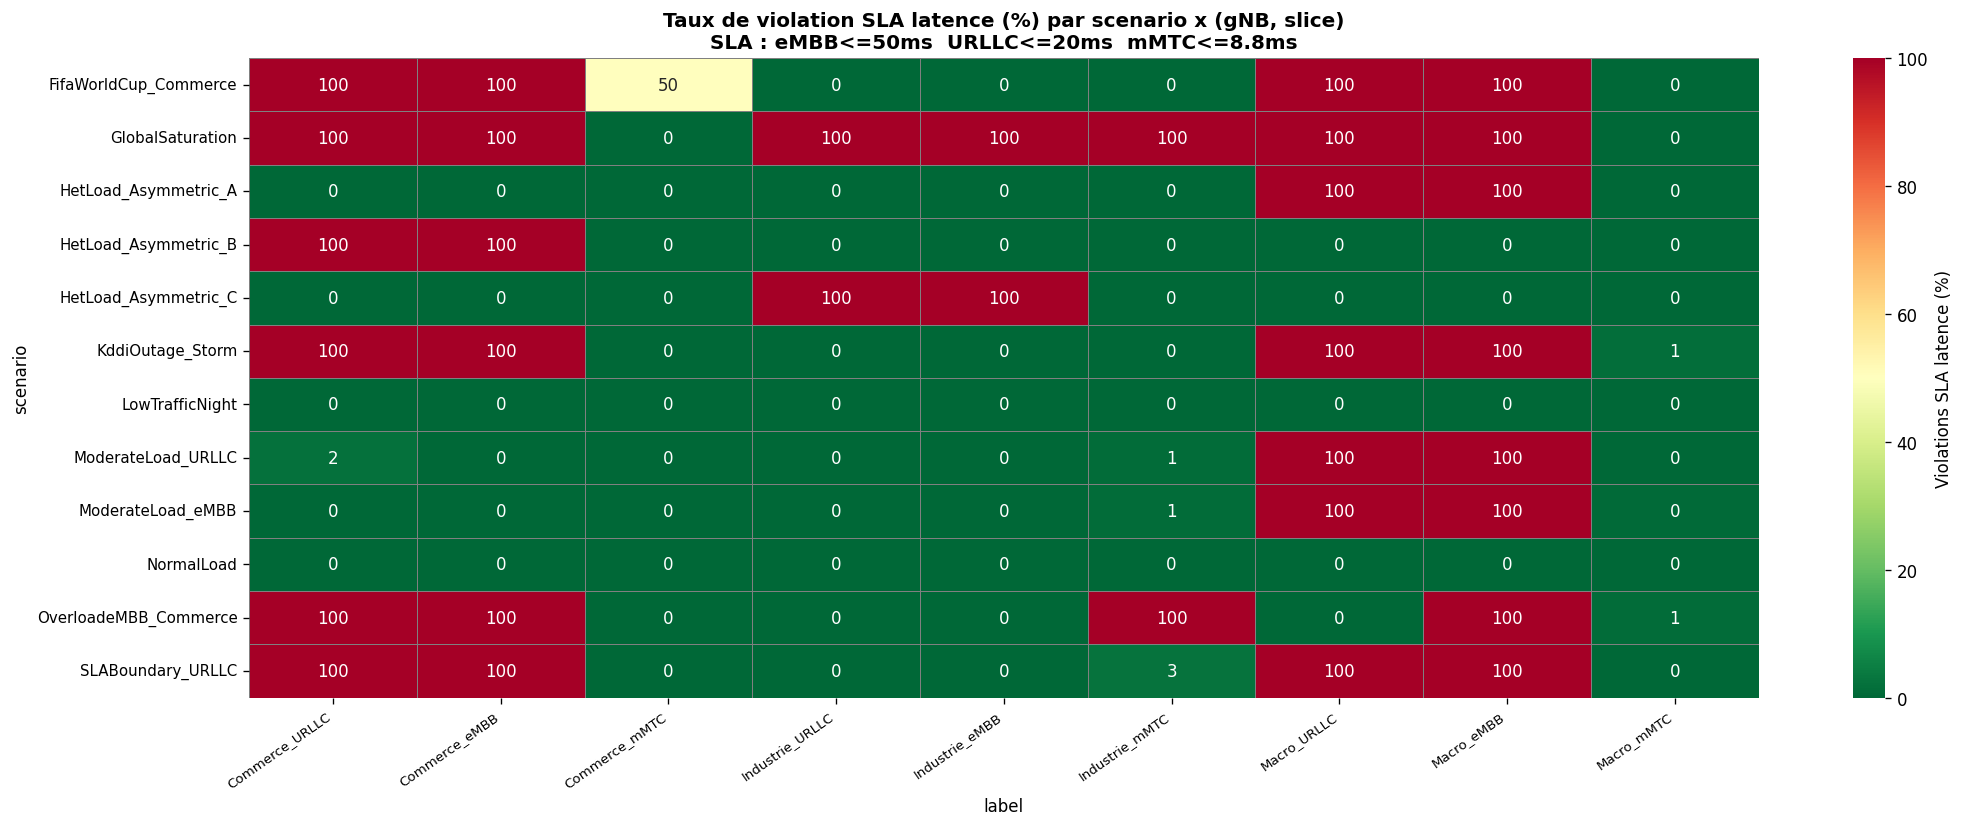

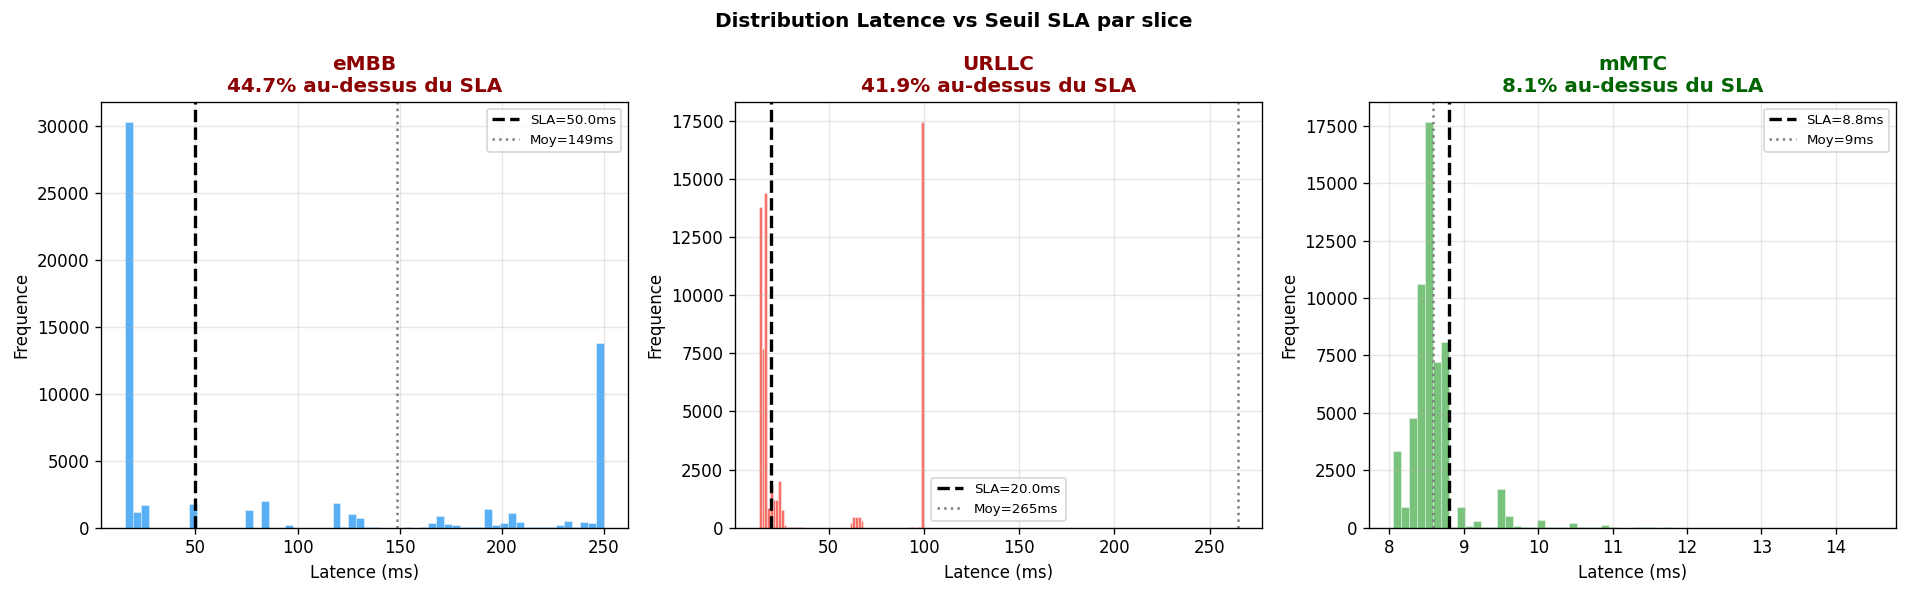

=== Latence max observee par scenario ===
slice                   URLLC    eMBB  mMTC
scenario                                   
FifaWorldCup_Commerce   671.9   268.6   9.0
GlobalSaturation       2488.8  1098.0  11.4
HetLoad_Asymmetric_A    176.9   947.7   8.7
HetLoad_Asymmetric_B   2489.1   348.9   8.7
HetLoad_Asymmetric_C    220.3  3541.6   8.7
KddiOutage_Storm         68.9   236.9   9.0
LowTrafficNight          15.0    18.5   8.9
ModerateLoad_URLLC      148.5   875.5  11.2
ModerateLoad_eMBB        27.9   192.2  14.5
NormalLoad               16.5    18.5   8.7
OverloadeMBB_Commerce  2490.5   287.4  11.7
SLABoundary_URLLC       113.8   118.7   9.0


In [35]:
## 9b. Heatmap violations + distribution latence
SLA_LATENCY = {'eMBB': 50.0, 'URLLC': 20.0, 'mMTC': 8.8}

# Recompute pour etre autonome
_sla_max = df['slice'].map(SLA_LATENCY) if 'SLA_Latency_Max_ms' not in df.columns else df['SLA_Latency_Max_ms']
_lat_viol = df['latency'] > _sla_max
viol_tbl = (_lat_viol.groupby([df['scenario'], df['gnb'], df['slice']])
                     .mean().mul(100).round(1).reset_index()
                     .rename(columns={0: 'viol_pct'}))
viol_tbl.columns = ['scenario', 'gnb', 'slice', 'viol_pct']

# --- Heatmap ---
viol_tbl['label'] = viol_tbl['gnb'] + '_' + viol_tbl['slice']
hm_viol = viol_tbl.pivot_table(index='scenario', columns='label', values='viol_pct')

fig, ax = plt.subplots(figsize=(18, 7))
sns.heatmap(hm_viol, annot=True, fmt='.0f', cmap='RdYlGn_r',
            vmin=0, vmax=100, linewidths=0.5, linecolor='gray',
            ax=ax, cbar_kws={'label': 'Violations SLA latence (%)'})
ax.set_title('Taux de violation SLA latence (%) par scenario x (gNB, slice)\n'
             'SLA : eMBB<=50ms  URLLC<=20ms  mMTC<=8.8ms',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR + '07_latency_sla_heatmap.png', bbox_inches='tight')
plt.show()

# --- Distribution par slice ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = {'eMBB': '#2196F3', 'URLLC': '#F44336', 'mMTC': '#4CAF50'}

for ax, sl in zip(axes, ['eMBB', 'URLLC', 'mMTC']):
    sub = df[df['slice'] == sl]['latency']
    sla = SLA_LATENCY[sl]
    viol_pct = (sub > sla).mean() * 100
    ax.hist(sub.clip(upper=sla * 5), bins=60, color=colors[sl],
            alpha=0.75, edgecolor='white', linewidth=0.3)
    ax.axvline(sla, color='black', linestyle='--', lw=2, label=f'SLA={sla}ms')
    ax.axvline(sub.mean(), color='gray', linestyle=':', lw=1.5, label=f'Moy={sub.mean():.0f}ms')
    ax.set_title(f'{sl}\n{viol_pct:.1f}% au-dessus du SLA', fontweight='bold',
                 color='darkred' if viol_pct > 10 else 'darkgreen')
    ax.set_xlabel('Latence (ms)')
    ax.set_ylabel('Frequence')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Distribution Latence vs Seuil SLA par slice', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '08_latency_distribution.png', bbox_inches='tight')
plt.show()

print('=== Latence max observee par scenario ===')
print(df.groupby(['scenario','slice'])['latency'].max().unstack().round(1).to_string())

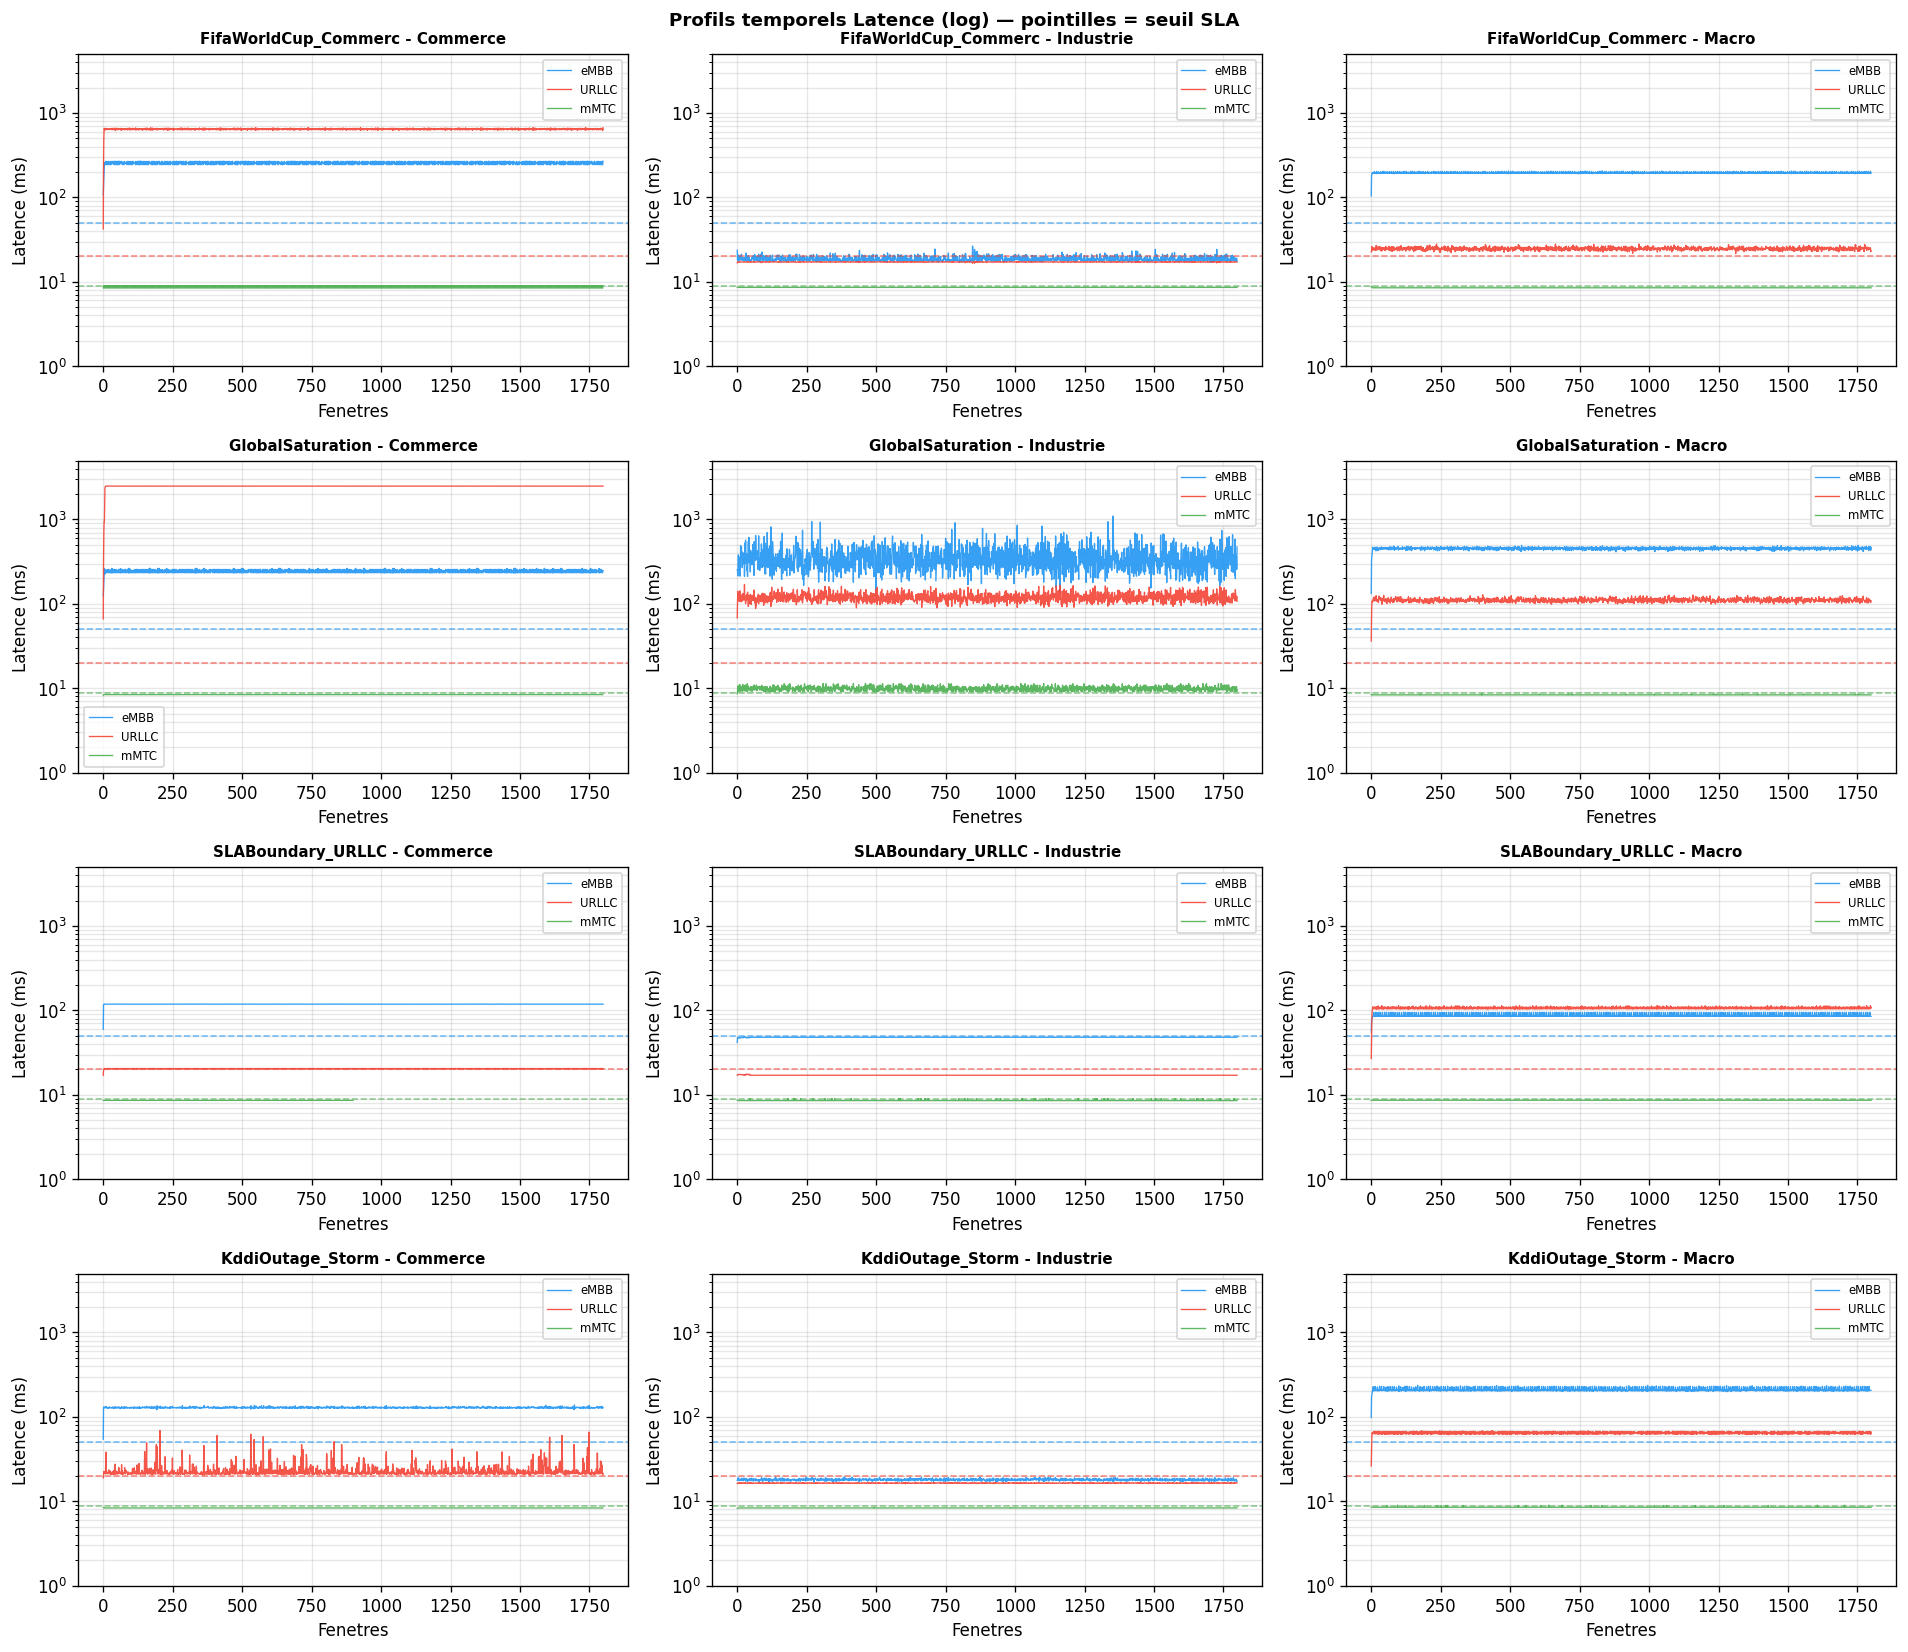

In [36]:
## 9c. Profils temporels latence (echelle log)
SLA_LATENCY = {'eMBB': 50.0, 'URLLC': 20.0, 'mMTC': 8.8}

scenarios_lat = [s for s in ['FifaWorldCup_Commerce', 'GlobalSaturation',
                              'SLABoundary_URLLC', 'KddiOutage_Storm']
                 if s in df['scenario'].unique()]

fig, axes = plt.subplots(len(scenarios_lat), 3, figsize=(16, 3.5 * len(scenarios_lat)))
if len(scenarios_lat) == 1:
    axes = [axes]

gnbs = sorted(df['gnb'].unique())
for row_axes, sc in zip(axes, scenarios_lat):
    sub = df[df['scenario'] == sc]
    for ax, gnb in zip(row_axes, gnbs):
        g = sub[sub['gnb'] == gnb]
        for sl, col in [('eMBB', '#2196F3'), ('URLLC', '#F44336'), ('mMTC', '#4CAF50')]:
            s = g[g['slice'] == sl].sort_values('Time_Sec')
            if s.empty:
                continue
            ax.plot(range(len(s)), s['latency'].values, color=col, lw=0.8, alpha=0.9, label=sl)
            ax.axhline(SLA_LATENCY[sl], color=col, linestyle='--', lw=1.0, alpha=0.6)
        ax.set_yscale('log')
        ax.set_ylim(1, 5000)
        ax.set_title(f'{sc[:20]} - {gnb}', fontsize=9, fontweight='bold')
        ax.set_xlabel('Fenetres')
        ax.set_ylabel('Latence (ms)')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3, which='both')

plt.suptitle('Profils temporels Latence (log) — pointilles = seuil SLA',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + '09_latency_temporal.png', bbox_inches='tight')
plt.show()